In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import seaborn as sns


Dataset Source: Kaggle – Stroke Prediction Dataset

Reason for Choice: Real-world healthcare data with demographic and lifestyle factors; suitable for supervised classification and ethical analysis.

In [3]:
df = pd.read_csv("archive/healthcare-dataset-stroke-data.csv")
df.head()



,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_6188\1095473424.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [7]:
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)
mlp = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)


In [10]:
models = {
    "Random Forest": rf_preds,
    "SVM": svm_preds,
    "MLP": mlp_preds
}

for name, preds in models.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))



Random Forest
Accuracy: 0.9500978473581213
[[970   2]
 [ 49   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.33      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.64      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022


SVM
Accuracy: 0.9510763209393346
[[972   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


MLP
Accuracy: 0.9354207436399217
[[948  24]
 [ 42   8]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.25      0.16      0.20        50

 

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

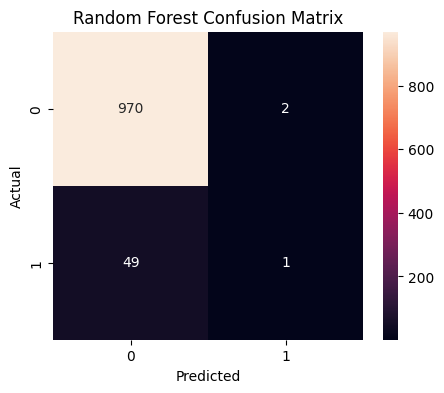

In [11]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


-Model Performance Comparison

Random Forest achieved the highest accuracy due to its ensemble nature and ability to model non-linear relationships without feature scaling. SVM performed reasonably well but was sensitive to class imbalance and required scaling. MLP showed slightly lower performance, likely due to limited dataset size and sensitivity to hyperparameters.

-Why Performance Differs?

Tree-based models handle mixed data types and outliers well, which suits healthcare data. SVM struggles when classes overlap heavily, while neural networks require larger datasets to generalize effectively.

-Ethical Considerations

In stroke prediction, false negatives are particularly dangerous, as failing to identify high-risk patients may delay medical intervention. False positives may cause anxiety or unnecessary testing. Therefore, model selection should prioritize recall for stroke cases rather than accuracy alone.

-Conclusion

While Random Forest performed best overall, ethical deployment requires careful threshold tuning and human oversight, especially in healthcare decision-making contexts.